**03_HOG_SVM_Baseline**

In [ ]:
import os
import cv2
import numpy as np
import random
import warnings

from pathlib import Path

from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Library berhasil dimuat")

Library berhasil dimuat


In [ ]:
IMG_SIZE = 256
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

SPLIT_PATH = Path(
    "/content/drive/MyDrive/Dataset ML/Dataset_Split"
)

CLASSES = ["Slingbag", "Totebag"]

In [ ]:
def flip_horizontal(img):
    return cv2.flip(img, 1)

def rotate(img, angle_range=(-15, 15)):
    angle = random.uniform(*angle_range)

    h, w = img.shape[:2]

    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0
    )

    return cv2.warpAffine(
        img,
        M,
        (w, h),
        borderMode=cv2.BORDER_REFLECT
    )

def adjust_brightness(
    img,
    factor_range=(0.6, 1.4)
):
    factor = random.uniform(
        *factor_range
    )

    return np.clip(
        img.astype(np.float32) * factor,
        0,
        255
    ).astype(np.uint8)

def add_gaussian_noise(
    img,
    std_range=(5, 20)
):
    std = random.uniform(*std_range)

    noise = np.random.normal(
        0,
        std,
        img.shape
    ).astype(np.float32)

    return np.clip(
        img.astype(np.float32) + noise,
        0,
        255
    ).astype(np.uint8)

def flip_and_rotate(img):
    return rotate(
        flip_horizontal(img)
    )

def brightness_and_noise(img):
    return add_gaussian_noise(
        adjust_brightness(img)
    )

AUGMENT_FUNCS = [
    flip_horizontal,
    rotate,
    adjust_brightness,
    add_gaussian_noise,
    flip_and_rotate,
    brightness_and_noise,
]

In [ ]:
def extract_hog(img):

    return hog(
        img,
        orientations=9,
        pixels_per_cell=(64,64),
        cells_per_block=(2,2),
        block_norm='L2-Hys',
        channel_axis=-1
    )

In [ ]:
X_train = []
y_train = []

for class_idx, class_name in enumerate(CLASSES):

    train_folder = (
        SPLIT_PATH /
        "train" /
        class_name
    )

    val_folder = (
        SPLIT_PATH /
        "validation" /
        class_name
    )

    X1, y1 = load_images(
        train_folder,
        class_idx
    )

    X2, y2 = load_images(
        val_folder,
        class_idx
    )

    X_train.extend(X1)
    X_train.extend(X2)

    y_train.extend(y1)
    y_train.extend(y2)

print("Training Samples:", len(X_train))

Training Samples: 850


In [ ]:
X_test = []
y_test = []

for class_idx, class_name in enumerate(CLASSES):

    test_folder = (
        SPLIT_PATH /
        "test" /
        class_name
    )

    X, y = load_images(
        test_folder,
        class_idx
    )

    X_test.extend(X)
    y_test.extend(y)

print("Test Samples:", len(X_test))

Test Samples: 150


In [ ]:
X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

print(X_train.shape)
print(X_test.shape)

(850, 324)
(150, 324)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Scaling selesai")

Scaling selesai


In [ ]:
svm = SVC(
    kernel="linear",
    C=1.0,
    random_state=RANDOM_STATE
)

svm.fit(
    X_train,
    y_train
)

print("Training selesai")

Training selesai


In [ ]:
y_pred = svm.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Akurasi Test: {accuracy*100:.2f}%"
)

Akurasi Test: 92.00%


In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=CLASSES
    )
)

              precision    recall  f1-score   support

    Slingbag       0.92      0.92      0.92        75
     Totebag       0.92      0.92      0.92        75

    accuracy                           0.92       150
   macro avg       0.92      0.92      0.92       150
weighted avg       0.92      0.92      0.92       150



<Figure size 600x500 with 0 Axes>

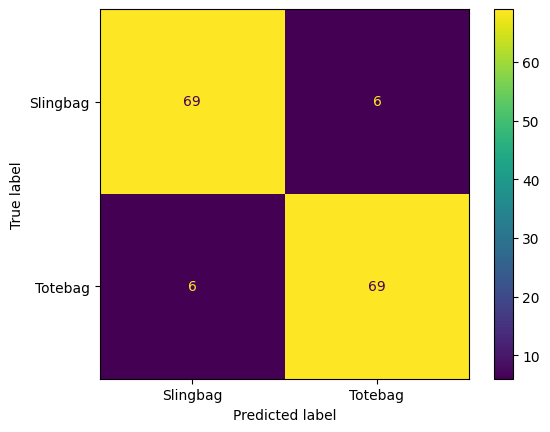

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASSES
)

disp.plot()

plt.show()

In [ ]:
y_pred_train = svm.predict(X_train)

train_acc = accuracy_score(
    y_train,
    y_pred_train
)

test_acc = accuracy_score(
    y_test,
    y_pred
)

gap = (
    train_acc -
    test_acc
) * 100

print(
    f"Train Accuracy : {train_acc*100:.2f}%"
)

print(
    f"Test Accuracy  : {test_acc*100:.2f}%"
)

print(
    f"Gap            : {gap:.2f}%"
)

Train Accuracy : 100.00%
Test Accuracy  : 92.00%
Gap            : 8.00%
